In [1]:
import selenium  
from selenium import webdriver 
import time
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import re
import pandas as pd
import numpy as np

In [2]:
options = Options()

options.add_argument('--start-maximized')              
options.add_argument('--disable-blink-features=AutomationControlled') 
options.add_argument('--disable-notifications')        

driver = webdriver.Chrome(options=options) 

In [3]:
driver.get('https://www.oyorooms.com/search/?location=Hyderabad%2C+Telangana%2C+India&city=Hyderabad')

time.sleep(5)

last_height = driver.execute_script(
    "return document.body.scrollHeight"
)

In [ ]:
scroll_count = 0 

while True:

    driver.execute_script(
        "window.scrollTo(0, document.body.scrollHeight);"
    )

    time.sleep(4)  
    new_height = driver.execute_script(
        "return document.body.scrollHeight"
    )

    scroll_count += 1
    print(f"Scroll {scroll_count} | Hotels loaded so far: {len(driver.find_elements(By.XPATH, '//h3'))}")

    if new_height == last_height: 
        break

    last_height = new_height

In [ ]:
total = len(driver.find_elements(By.XPATH, '//h3'))
print(f"\nTotal hotels found after scrolling: {total}")

TARGET = total  


Names = []

brand_tag = driver.find_elements(By.XPATH, '//h3')

for i in brand_tag:
    a = i.text
    Names.append(a)

In [ ]:
Locations = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//span[@itemprop="streetAddress"]'
)

for i in brand_tag:
    a = i.text
    Locations.append(a)

while len(Locations) < TARGET:  
    Locations.append(np.nan)

In [ ]:
Ratings_count = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//*[contains(text(),"Ratings")]'
)

for i in brand_tag:
    a = i.text
    b = re.findall(r'\d+', a) 

    if len(b) > 0:
        Ratings_count.append(b[0])

while len(Ratings_count) < TARGET:
    Ratings_count.append(np.nan)

In [ ]:
taxes = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//span[contains(text(),"taxes")]'
)

for i in brand_tag:
    a = i.text
    b = re.findall(r'₹\d+', a)  

    if len(b) > 0:
        taxes.append(b[0])

while len(taxes) < TARGET:
    taxes.append(np.nan)

In [ ]:
Features = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//div[@class="amenityWrapper"]'
)

for i in brand_tag:
    a = i.text.replace('\n', ', ')  
    Features.append(a)

while len(Features) < TARGET:
    Features.append(np.nan)

In [ ]:
discount = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//span[contains(@class,"listingPrice__percentage")]'
)

for i in brand_tag:
    a = i.text
    b = re.findall(r'\d+% off', a)  

    if len(b) > 0:
        discount.append(b[0])

while len(discount) < TARGET:
    discount.append(np.nan)

In [ ]:
prices = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//span[contains(@class,"listingPrice__finalPrice")]'
)

for i in brand_tag:
    a = i.text
    b = re.findall(r'\d+', a) 

    if len(b) > 0:
        prices.append(b[0])

while len(prices) < TARGET:
    prices.append(np.nan)

In [ ]:
membership = []

cards = driver.find_elements(
    By.XPATH,
    '//div[contains(@class,"listingHotelDescription")]'
)

cards = cards[:TARGET]  

for i in cards:
    if "WIZARD MEMBER" in i.text:         
        membership.append("WIZARD MEMBER")
    else:
        membership.append("Not a Member")

while len(membership) < TARGET:
    membership.append(np.nan)

In [ ]:
star_category = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//span[contains(@class,"hotelCategory") or contains(text(),"Star")]'
)

for i in brand_tag:
    a = i.text
    if a.strip() != "":
        star_category.append(a.strip())

while len(star_category) < TARGET:
    star_category.append(np.nan)

In [ ]:
ratings_score = []

brand_tag = driver.find_elements(
    By.XPATH,
    '//div[contains(@class,"listingRating__score")] | //span[contains(@class,"ratingScore")]'
)

for i in brand_tag:
    a = i.text
    b = re.findall(r'\d+\.?\d*', a) 

    if len(b) > 0:
        ratings_score.append(b[0])

while len(ratings_score) < TARGET:
    ratings_score.append(np.nan)

In [ ]:
df1 = pd.DataFrame({
    "Names"         : Names,
    "Locations"     : Locations,
    "Prices"        : prices,
    "Taxes"         : taxes,
    "Discount"      : discount,
    "Ratings_Count" : Ratings_count,
    "Ratings_Score" : ratings_score,
    "Features"      : Features,
    "Membership"    : membership,
    "Star_Category" : star_category
})

In [ ]:
len(Names)

len(prices)

len(discount)

len(Features)

len(membership)

len(taxes)

df1=pd.DataFrame({"Names":Names,"Locatios":Locations,"prices":prices,"taxes":taxes,"discount":discount,"Ratings_count":Ratings_count,"Features":Features,"membership":membership})

In [ ]:
df1["Prices"] = (
    df1["Prices"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [ ]:
df1["Discount"] = (
    df1["Discount"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("off", "", regex=False)
    .str.strip()
    .astype(float)
)

#### Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1=pd.read_csv(r"C:\Users\chand\Downloads\oyo_final.csv")

In [38]:
df1.sample(10)

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Ratings_Score,Features,Membership,Star_Category,Price_After_Discount
582,Super Hotel O Laxmi Narsimha Temple Banjara Hills,"Banjara Hills, Hyderabad",NaN,NaN,NaN,4.0,NaN,"Reception, Free Wifi, Power backup, + 10 more",Not a Member,NaN,NaN
332,Hotel O Qualia Nallagandla,"Rangareddy, Hyderabad",1277.0,₹174,72% off,22.0,NaN,"Elevator, 24-Hour Front Desk, Free Wifi, + 6 more",Not a Member,NaN,1277.0
38,OYO Townhouse 73513 Ibrahimpatnam,"Ibrahimpatnam, Hyderabad",2833.0,340,27.15% off,618.0,4.0,AC | Hot Water | TV | Laundry,OYO Wizard Silver,2 Star,2833.0
391,Townhouse Kukatpally Formerly SV Royal,"Near Nizampet Bus Stop, Hyderabad",1019.0,₹153,72% off,1139.0,NaN,"Reception, 24x7 Facility Manager, Free Wifi, +...",WIZARD MEMBER,NaN,1019.0
134,OYO Hotel 74306 Kothur,"Kothur, Hyderabad",3988.0,718,21.87% off,401.0,3.7,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,3988.0
30,OYO Collection O 73431 Ibrahimpatnam,"Ibrahimpatnam, Hyderabad",761.0,91,60.34% off,2327.0,4.2,Free WiFi | AC | Swimming Pool | Gym | Restaurant,NaN,2 Star,761.0
212,Hotel O Raja Residency Near Snow World,"Near Raja Deluxe Complex, Musheerabad, Hyderabad",807.0,₹135,72% off,491.0,NaN,"Private entrance, Parking facility, Reception,...",Not a Member,NaN,807.0
450,Super Hotel O RB STAY,"Ranjendra path, ulidih",1025.0,₹148,71% off,3.0,NaN,"Free Wifi, Geyser, Power backup, + 3 more",Not a Member,NaN,1025.0
282,Super Townhouse Qualia Prime,"Phase 9, Hyderabad",1320.0,₹178,71% off,388.0,NaN,"24-Hour Front Desk, Free Wifi, Geyser, + 4 more",WIZARD MEMBER,NaN,1320.0
59,OYO Flagship 73717 Kompally,"Kompally, Hyderabad",1446.0,260,43.14% off,2404.0,4.7,Free WiFi | AC | TV | Parking,NaN,3 Star,1446.0


In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Names                 626 non-null    str    
 1   Locations             626 non-null    str    
 2   Prices                565 non-null    float64
 3   Taxes                 565 non-null    str    
 4   Discount              565 non-null    str    
 5   Ratings_Count         590 non-null    float64
 6   Ratings_Score         160 non-null    float64
 7   Features              626 non-null    str    
 8   Membership            580 non-null    str    
 9   Star_Category         160 non-null    str    
 10  Price_After_Discount  565 non-null    float64
dtypes: float64(4), str(7)
memory usage: 133.3 KB


In [25]:
df1.isna().sum()

Names                     0
Locations                 0
Prices                   61
Taxes                    61
Discount                 61
Ratings_Count            36
Ratings_Score           466
Features                  0
Membership               46
Star_Category           466
Price_After_Discount     61
dtype: int64

In [41]:
df1["Prices"] = df1["Prices"].fillna(df1["Prices"].median())

In [42]:
df1["Taxes"] = (
    df1["Taxes"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

In [43]:
df1["Taxes"]=df1["Taxes"].fillna(df1['Taxes'].median())

In [44]:
df1["Discount"] = (
    df1["Discount"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("off", "", regex=False)
    .str.strip()
    .astype(float)
)

In [ ]:
df1.insert(
    df1.columns.get_loc("Discount") + 1,
    "Price_after_discount",
    df1["Prices"] - (df1["Prices"] * df1["Discount"] / 100)
)

In [45]:
df1["Discount"] = df1["Discount"].astype(float)

In [46]:
df1["Discount"]=df1["Discount"].fillna(df1['Discount'].median())

In [47]:
df1["Ratings_Count"]=df1["Ratings_Count"].fillna(df1['Ratings_Count'].median())

In [48]:
df1["Ratings_Score"]=df1["Ratings_Score"].fillna(df1['Ratings_Score'].median())

In [49]:
df1["Price_After_Discount"]=df1["Price_After_Discount"].fillna(df1['Price_After_Discount'].median())

In [50]:
df1["Membership"]=df1["Membership"].fillna(df1["Membership"].mode()[0])

In [51]:
df1["Star_Category"]=df1["Star_Category"].fillna(df1["Star_Category"].mode()[0])

In [52]:
df1.drop("Ratings_Score", axis=1, inplace=True)

In [53]:
df1.select_dtypes(include="number").columns

Index(['Prices', 'Taxes', 'Discount', 'Ratings_Count', 'Price_After_Discount'], dtype='str')

In [55]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Names                 626 non-null    str    
 1   Locations             626 non-null    str    
 2   Prices                626 non-null    float64
 3   Taxes                 626 non-null    float64
 4   Discount              626 non-null    float64
 5   Ratings_Count         626 non-null    float64
 6   Features              626 non-null    str    
 7   Membership            626 non-null    str    
 8   Star_Category         626 non-null    str    
 9   Price_After_Discount  626 non-null    float64
dtypes: float64(5), str(5)
memory usage: 124.2 KB


In [60]:
def give_outliers_info(dataframe,columns):
    for col_name in columns:
        q1 = dataframe[col_name].quantile(0.25)
        q3 =dataframe[col_name].quantile(0.75)
        IQR = q3-q1
        LL = q1-1.5*IQR
        RL = q3 +1.5*IQR
        outliers= len(dataframe) - sum(dataframe[col_name].between(LL,RL))
        print('no of outliers - ',col_name, outliers)

In [63]:
give_outliers_info(df1, ['Prices', 'Taxes', 'Discount', 'Ratings_Count',
       'Price_After_Discount',]) 

no of outliers -  Prices 70
no of outliers -  Taxes 82
no of outliers -  Discount 146
no of outliers -  Ratings_Count 8
no of outliers -  Price_After_Discount 70


In [64]:
def reduce_outliers(dataframe, columns):
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        dataframe[col] = np.where(dataframe[col] > upper_limit, upper_limit, dataframe[col])
        dataframe[col] = np.where(dataframe[col] < lower_limit, lower_limit, dataframe[col])

In [66]:
reduce_outliers(df1,['Prices', 'Taxes', 'Discount', 'Ratings_Count', 
       'Price_After_Discount', ])

In [68]:
give_outliers_info(df1, ['Prices', 'Taxes', 'Discount', 'Ratings_Count', 
       'Price_After_Discount', ]) 

no of outliers -  Prices 0
no of outliers -  Taxes 0
no of outliers -  Discount 0
no of outliers -  Ratings_Count 0
no of outliers -  Price_After_Discount 0


##### Boolean Masking 

In [80]:
#1.Hotels with price greater than 2000
df1[df1["Prices"] > 2000]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.000,259.0,59.8,2484.0,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,3 Star,2155.000,35.35
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.000,258.0,59.8,2586.0,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.000,39.96
6,OYO Townhouse 73233 Shamshabad,"Shamshabad, Hyderabad",2115.000,328.0,59.8,2666.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Black,2 Star,2115.000,35.35
10,OYO Collection O 73285 Shamshabad,"Shamshabad, Hyderabad",2595.625,328.0,59.8,2402.0,AC | Hot Water | TV | Laundry,OYO Wizard Gold,Unrated,2595.625,39.46
11,OYO Collection O 73288 Shamshabad,"Shamshabad, Hyderabad",2595.625,314.0,59.8,461.0,AC | TV | Hot Water | Room Service,OYO Wizard Black,3 Star,2595.625,41.35
...,...,...,...,...,...,...,...,...,...,...,...
447,Hotel O Siro Inn,"Brindavan Colonynull, Hyderabad",2595.625,328.0,68.0,14.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,2595.625,68.00
458,Spot On Sunshine Inn,"Near Hanuman Temple, Chandanagar, Hyderabad",2595.625,314.0,68.0,1.0,"24-Hour Front Desk, Free Wifi, Daily housekeep...",Not a Member,2 Star,2595.625,68.00
492,Hotel O Khyaathi Grand,"madhapur, Hyderabad",2595.625,328.0,68.0,40.0,"Elevator, Free Wifi, Geyser, + 3 more",Not a Member,2 Star,2595.625,68.00
497,Hotel O by OYO Krupa Service Apartments,"Near puri jagannadh temple, Bhavani Nagar, Hyd...",2595.625,318.0,72.0,102.0,"Parking facility, Reception, Free Wifi, + 12 more",Not a Member,2 Star,2595.625,72.00


In [79]:
#2.Hotels with rating above 4
df1[df1["Taxes"] < 300]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126.0,59.80,431.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0,53.33
1,OYO Townhouse 73202 Shamshabad,"Shamshabad, Hyderabad",1551.0,186.0,59.80,2673.0,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1551.0,48.30
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.0,259.0,59.80,2484.0,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,3 Star,2155.0,35.35
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.0,258.0,59.80,2586.0,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.0,39.96
...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.00,382.0,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.00,382.0,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


In [78]:
#3. Hotels with taxes less than 300
df1[df1["Taxes"] < 300]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126.0,59.80,431.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0,53.33
1,OYO Townhouse 73202 Shamshabad,"Shamshabad, Hyderabad",1551.0,186.0,59.80,2673.0,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1551.0,48.30
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.0,259.0,59.80,2484.0,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,3 Star,2155.0,35.35
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.0,258.0,59.80,2586.0,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.0,39.96
...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.00,382.0,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.00,382.0,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


In [76]:
#4. Hotels with discount greater than 50
df1[df1["Discount"] > 50]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126.0,59.80,431.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0,53.33
1,OYO Townhouse 73202 Shamshabad,"Shamshabad, Hyderabad",1551.0,186.0,59.80,2673.0,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1551.0,48.30
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.0,259.0,59.80,2484.0,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,3 Star,2155.0,35.35
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.0,258.0,59.80,2586.0,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.0,39.96
...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.00,382.0,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.00,382.0,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


In [72]:
#5. Hotels with price after discount below 1000
df1[df1["Price_After_Discount"] < 1000]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Ratings_Score,Features,Membership,Star_Category,Price_After_Discount,Discounnt
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126.0,59.80,431.0,3.9,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0,53.33
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,3.9,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
12,OYO Collection O 73295 Shamshabad,"Shamshabad, Hyderabad",859.0,155.0,59.80,1929.0,3.9,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,Unrated,859.0,55.72
20,OYO Life 73340 Shadnagar,"Shadnagar, Hyderabad",840.0,101.0,59.80,1365.0,3.9,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,2 Star,840.0,35.35
22,OYO Townhouse 73355 Shadnagar,"Shadnagar, Hyderabad",985.0,118.0,62.60,1746.0,3.9,AC | Hot Water | TV | Laundry,OYO Wizard Gold,3 Star,985.0,62.60
...,...,...,...,...,...,...,...,...,...,...,...,...
554,Townhouse Oak Hyderabad Miyapur Metro Station,"Miyapur Road, Hyderabad",754.0,120.0,67.00,2217.0,3.9,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,754.0,67.00
559,Super Collection O White Field Road Hyderabad ...,"Gachibowli, Hyderabad",985.0,144.0,72.00,335.0,3.9,"Free Wifi, AC, Power backup, + 18 more",Not a Member,2 Star,985.0,72.00
560,Hotel O 11 Eleven,"Medipally x road Boduppal, Hyderabad",921.0,136.0,71.00,546.0,3.9,"Elevator, Free Wifi, Geyser, + 4 more",WIZARD MEMBER,2 Star,921.0,71.00
562,Super Collection O Secunderabad-II,"Near Veg Market, Bowenpally, Hyderabad",992.0,144.0,72.00,440.0,3.9,"Dining area, Reception, AC, + 27 more",Not a Member,2 Star,992.0,72.00


In [74]:
#6. Hotels with rating above 4 and price below 1500
df1[(df1["Ratings_Count"] > 4) & (df1["Prices"] < 1500)]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Ratings_Score,Features,Membership,Star_Category,Price_After_Discount,Discounnt
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126.0,59.80,431.0,3.9,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0,53.33
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,3.9,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
7,OYO Townhouse 73245 Shamshabad,"Shamshabad, Hyderabad",1268.0,228.0,59.80,2633.0,3.9,Free WiFi | AC | Breakfast Included | Parking ...,OYO Wizard Black,Unrated,1268.0,45.93
12,OYO Collection O 73295 Shamshabad,"Shamshabad, Hyderabad",859.0,155.0,59.80,1929.0,3.9,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,Unrated,859.0,55.72
20,OYO Life 73340 Shadnagar,"Shadnagar, Hyderabad",840.0,101.0,59.80,1365.0,3.9,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,2 Star,840.0,35.35
...,...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.00,382.0,3.9,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,3.9,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,3.9,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.00,382.0,3.9,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


In [82]:
#7. Hotels with taxes above 500 or discount above 70
df1[(df1["Taxes"] > 500) | (df1["Discount"] > 70)]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
32,OYO Flagship 73458 Ibrahimpatnam,"Ibrahimpatnam, Hyderabad",637.0,115.0,71.16,421.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,3 Star,637.0,71.16
34,OYO Collection O 73472 Ibrahimpatnam,"Ibrahimpatnam, Hyderabad",631.0,114.0,72.43,562.0,AC | TV | Parking | 24hr Reception | Power Backup,OYO Wizard Silver,2 Star,631.0,72.43
102,OYO Premium 74070 Chevella,"Chevella, Hyderabad",777.0,140.0,70.14,1573.0,AC | Hot Water | TV | Laundry,Not a Member,3 Star,777.0,70.14
160,Super Townhouse Narayanaguda Metro Station For...,"Near Old MLA Quarters, Himayathnagar, Hyderabad",1539.0,237.0,72.00,1468.0,"Parking facility, Dining area, Free Wifi, + 21...",WIZARD MEMBER,2 Star,1539.0,72.00
...,...,...,...,...,...,...,...,...,...,...,...
560,Hotel O 11 Eleven,"Medipally x road Boduppal, Hyderabad",921.0,136.0,71.00,546.0,"Elevator, Free Wifi, Geyser, + 4 more",WIZARD MEMBER,2 Star,921.0,71.00
561,Hotel O Happy Homes,"Tarnaka, Hyderabad",1024.0,148.0,71.00,34.0,"24-Hour Front Desk, Free Wifi, Geyser, + 5 more",WIZARD MEMBER,2 Star,1024.0,71.00
562,Super Collection O Secunderabad-II,"Near Veg Market, Bowenpally, Hyderabad",992.0,144.0,72.00,440.0,"Dining area, Reception, AC, + 27 more",Not a Member,2 Star,992.0,72.00
563,Hotel O Sai Residency,"Near Sr nagar metro station, Jawahar Nagar, Hy...",1165.0,162.0,72.00,208.0,"Dining area, Reception, Free Wifi, + 14 more",Not a Member,2 Star,1165.0,72.00


In [85]:
#8. Hotels not having ratings below 3
df1[~(df1["Ratings_Count"] < 3)]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126.0,59.80,431.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0,53.33
1,OYO Townhouse 73202 Shamshabad,"Shamshabad, Hyderabad",1551.0,186.0,59.80,2673.0,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1551.0,48.30
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.0,259.0,59.80,2484.0,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,3 Star,2155.0,35.35
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.0,258.0,59.80,2586.0,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.0,39.96
...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.00,382.0,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.00,382.0,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


In [86]:
#9. Hotels where final price is greater than original price
df1[df1["Price_After_Discount"] > df1["Prices"]]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt


In [87]:
#10. Hotels with prices between 1000 and 3000
df1[(df1["Prices"] >= 1000) & (df1["Prices"] <= 3000)]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
1,OYO Townhouse 73202 Shamshabad,"Shamshabad, Hyderabad",1551.0,186.0,59.8,2673.0,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1551.0,48.30
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.0,259.0,59.8,2484.0,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,3 Star,2155.0,35.35
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.0,258.0,59.8,2586.0,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.0,39.96
5,OYO Life 73227 Shamshabad,"Shamshabad, Hyderabad",1532.0,276.0,59.8,425.0,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1532.0,35.35
6,OYO Townhouse 73233 Shamshabad,"Shamshabad, Hyderabad",2115.0,328.0,59.8,2666.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Black,2 Star,2115.0,35.35
...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.0,382.0,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.0,382.0,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.0,382.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.0,382.0,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


In [89]:
#11. Top expensive hotels with high ratings
df1[(df1["Prices"] > 3000) & (df1["Ratings_Count"] > 4.5)]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt


In [90]:
#12. Hotels giving highest discounts but low ratings
df1[(df1["Discount"] > 70) & (df1["Ratings_Count"] < 3)]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
254,Hotel O RAGA GRAND HOTEL,"INDIA, Hyderabad",1025.0,148.0,71.0,2.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1025.0,71.0
285,HOTEL O ZESTORA,"Telangana , Hyderabad",1152.0,162.0,72.0,1.0,"Elevator, Free Wifi, Geyser, + 4 more",Not a Member,2 Star,1152.0,72.0
407,HOTEL O LANCO TECHNO PARK.,"Centrally Located, Near Huda Park, Kukatpally,...",912.0,136.0,71.0,1.0,"Dining area, Reception, Caretaker, + 26 more",Not a Member,2 Star,912.0,71.0
415,Super Townhouse SR Nagar Near RCC Premier,"SR Nagar, Hyderabad",956.0,140.0,72.0,2.0,"Elevator, 24-Hour Front Desk, Free Wifi, + 6 more",Not a Member,2 Star,956.0,72.0
427,Super Townhouse Gachibowli Flyover Hyderabad,"Ranga Reddy, Hyderabad",1524.0,210.0,72.0,2.0,"Elevator, Free Wifi, Geyser, + 8 more",Not a Member,2 Star,1524.0,72.0
431,Super Townhouse RCC Sunrise,"Near Begumpet lifestyle, Kundanbagh Colony, Hy...",1025.0,148.0,71.0,1.0,"Private entrance, Reception, Dining area, + 22...",WIZARD MEMBER,2 Star,1025.0,71.0
432,Super Collection O Madhapur Near Cyber Tower,"Near Borabanda Railway Station, Hyderabad",926.0,138.0,72.0,1.0,"Parking facility, Reception, 24x7 Facility Man...",Not a Member,2 Star,926.0,72.0
434,Hotel O RB Comfort,"Telangana 500055 Hyderabad, Hyderabad",883.0,137.0,72.0,1.0,"Elevator, Free Wifi, Geyser, + 4 more",Not a Member,2 Star,883.0,72.0
437,Townhouse Whiteridge Gachibowli Near AIG Hospital,"Gachibowli, Hyderabad",1165.0,162.0,71.0,2.0,"Dining area, Reception, Cot, + 43 more",Not a Member,2 Star,1165.0,71.0
451,HOTEL RKS Near by Narsingi,"Kokapet, Hyderabad",1142.0,160.0,71.0,1.0,"AC, TV",Not a Member,2 Star,1142.0,71.0


In [91]:
#13. Budget-friendly hotels with excellent ratings
df1[(df1["Price_After_Discount"] < 1500) & (df1["Ratings_Count"] > 4)]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126.0,59.80,431.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0,53.33
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
7,OYO Townhouse 73245 Shamshabad,"Shamshabad, Hyderabad",1268.0,228.0,59.80,2633.0,Free WiFi | AC | Breakfast Included | Parking ...,OYO Wizard Black,Unrated,1268.0,45.93
12,OYO Collection O 73295 Shamshabad,"Shamshabad, Hyderabad",859.0,155.0,59.80,1929.0,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,Unrated,859.0,55.72
20,OYO Life 73340 Shadnagar,"Shadnagar, Hyderabad",840.0,101.0,59.80,1365.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,2 Star,840.0,35.35
...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.00,382.0,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.00,382.0,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


In [92]:
#14. Hotels with very high taxes
df1[df1["Taxes"] > df1["Taxes"].mean()]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.0,259.0,59.8,2484.00,AC | TV | Parking | 24hr Reception | Power Backup,Not a Member,3 Star,2155.0,35.35
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.0,258.0,59.8,2586.00,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.0,39.96
5,OYO Life 73227 Shamshabad,"Shamshabad, Hyderabad",1532.0,276.0,59.8,425.00,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1532.0,35.35
6,OYO Townhouse 73233 Shamshabad,"Shamshabad, Hyderabad",2115.0,328.0,59.8,2666.00,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Black,2 Star,2115.0,35.35
7,OYO Townhouse 73245 Shamshabad,"Shamshabad, Hyderabad",1268.0,228.0,59.8,2633.00,Free WiFi | AC | Breakfast Included | Parking ...,OYO Wizard Black,Unrated,1268.0,45.93
...,...,...,...,...,...,...,...,...,...,...,...
516,HOTEL O VASISTA RESIDENCY,"Near Company Bagh, Jalandhar",1286.0,196.0,71.0,135.00,"Reception, Free Wifi, Caretaker, + 14 more",Not a Member,2 Star,1286.0,71.00
518,Hotel O A R International,"Main Road Shamshabad, Hyderabad",2351.0,303.0,72.0,456.00,"Parking facility, Dining area, Free Wifi, + 12...",Not a Member,2 Star,2351.0,72.00
521,HOTEL O NEXUS,"IBRAHIMPATNAM, Hyderabad",1707.0,210.0,68.0,351.00,"Elevator, Free Wifi, Geyser, + 4 more",Not a Member,2 Star,1707.0,68.00
539,OYO 77966 F5 Hospitality,"Centrally Located, Near Huda Park, Kukatpally,...",1362.0,214.0,68.0,26.00,"Elevator, Free Wifi, Geyser, + 4 more",Not a Member,2 Star,1362.0,68.00


In [93]:
#15. Hotels with discount greater than average discount
df1[df1["Discount"] > df1["Discount"].mean()]

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Features,Membership,Star_Category,Price_After_Discount,Discounnt
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75.0,73.45,1150.0,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0,73.45
32,OYO Flagship 73458 Ibrahimpatnam,"Ibrahimpatnam, Hyderabad",637.0,115.0,71.16,421.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,3 Star,637.0,71.16
34,OYO Collection O 73472 Ibrahimpatnam,"Ibrahimpatnam, Hyderabad",631.0,114.0,72.43,562.0,AC | TV | Parking | 24hr Reception | Power Backup,OYO Wizard Silver,2 Star,631.0,72.43
62,OYO Collection O 73742 Kompally,"Kompally, Hyderabad",709.0,128.0,68.08,123.0,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Black,2 Star,709.0,68.08
102,OYO Premium 74070 Chevella,"Chevella, Hyderabad",777.0,140.0,70.14,1573.0,AC | Hot Water | TV | Laundry,Not a Member,3 Star,777.0,70.14
...,...,...,...,...,...,...,...,...,...,...,...
621,Townhouse Oak Townhouse Oak BN Reddy Formerly ...,"Hayathnagar, Hyderabad",1229.0,170.0,68.00,382.0,"AC, TV",WIZARD MEMBER,2 Star,1229.0,NaN
622,Villa Verizon by Dancenter,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Reception, Free Wifi, Iron, + 16 more",Not a Member,2 Star,1229.0,NaN
623,Townhouse Oak Umdanagar Railway Station,"Shamshabad, Hyderabad",1229.0,170.0,68.00,382.0,"Free Wifi, Geyser, Power backup, + 2 more",Not a Member,2 Star,1229.0,NaN
624,Super Hotel O Kompally City Mall Formerly Srim...,"Kompally, Hyderabad",1229.0,170.0,68.00,382.0,"Elevator, Reception, Free Wifi, + 7 more",Not a Member,2 Star,1229.0,NaN


<Axes: >

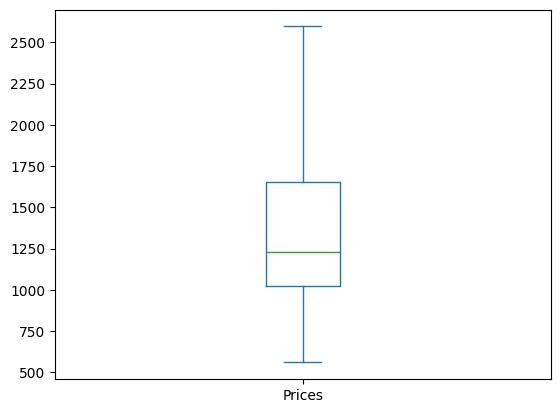

In [94]:
df1["Prices"].plot(kind="box")

<Axes: >

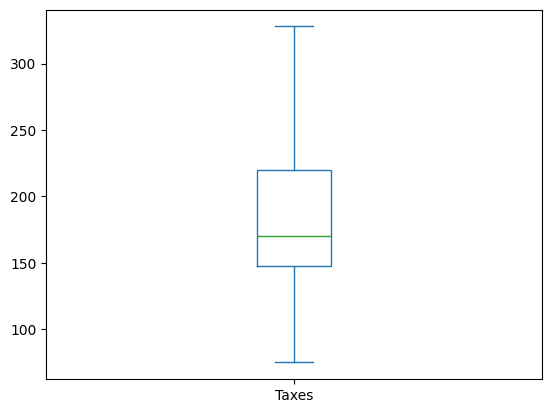

In [95]:
df1['Taxes'].plot(kind='box')

<Axes: >

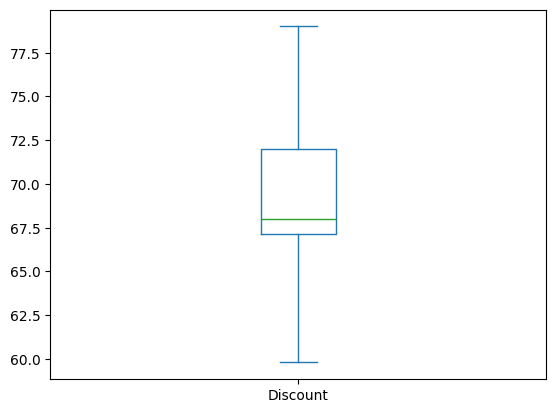

In [96]:
df1['Discount'].plot(kind="box")

<Axes: >

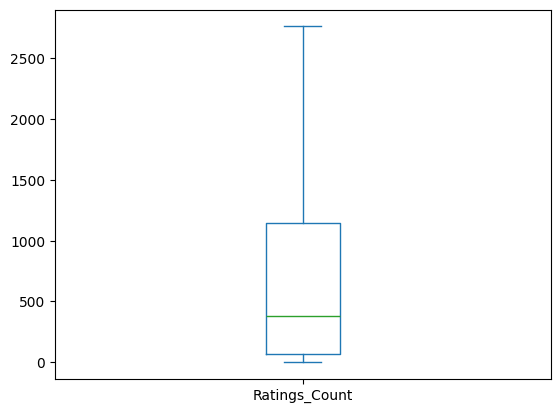

In [98]:
df1["Ratings_Count"].plot(kind="box")

<Axes: >

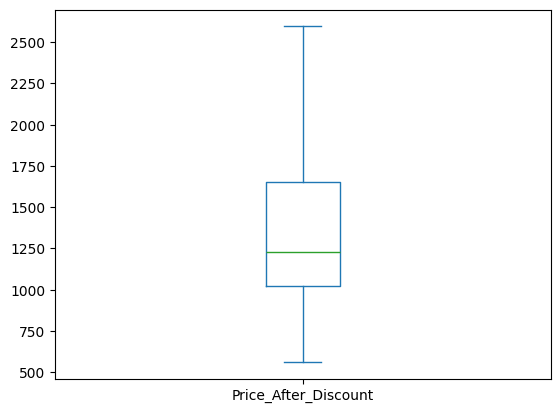

In [99]:
df1['Price_After_Discount'].plot(kind="box")


#### Data Visualization

In [4]:
df1.head()

,Names,Locations,Prices,Taxes,Discount,Ratings_Count,Ratings_Score,Features,Membership,Star_Category,Price_After_Discount
0,OYO Flagship 73200 Shamshabad,"Shamshabad, Hyderabad",701.0,126,53.33% off,431.0,3.3,Free WiFi | AC | Hot Water | 24hr Reception,OYO Wizard Gold,1 Star,701.0
1,OYO Townhouse 73202 Shamshabad,"Shamshabad, Hyderabad",1551.0,186,48.3% off,2673.0,3.2,AC | Hot Water | TV | Laundry,OYO Wizard Silver,3 Star,1551.0
2,OYO Studio 73215 Shamshabad,"Shamshabad, Hyderabad",625.0,75,73.45% off,1150.0,3.7,AC | TV | Hot Water | Room Service,OYO Wizard Silver,3 Star,625.0
3,OYO Flagship 73217 Shamshabad,"Shamshabad, Hyderabad",2155.0,259,32.45% off,2484.0,4.6,AC | TV | Parking | 24hr Reception | Power Backup,NaN,3 Star,2155.0
4,OYO Flagship 73226 Shamshabad,"Shamshabad, Hyderabad",2149.0,258,39.96% off,2586.0,3.4,Free WiFi | AC | Swimming Pool | Gym | Restaurant,OYO Wizard Gold,3 Star,2149.0


##### Univariat analysis

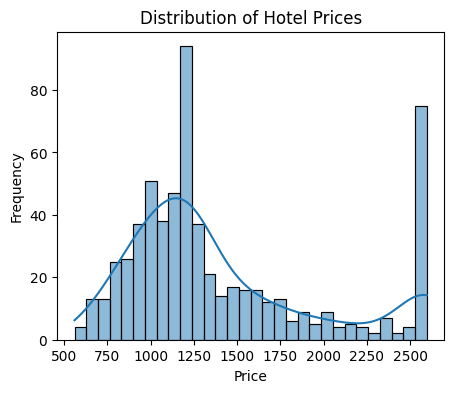

In [135]:
plt.figure(figsize=(5,4))
sns.histplot(df1['Prices'], bins=30, kde=True)
plt.title('Distribution of Hotel Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

C:\Users\chand\AppData\Local\Temp\ipykernel_16824\241776564.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_loc.values, y=top_loc.index, palette="viridis")


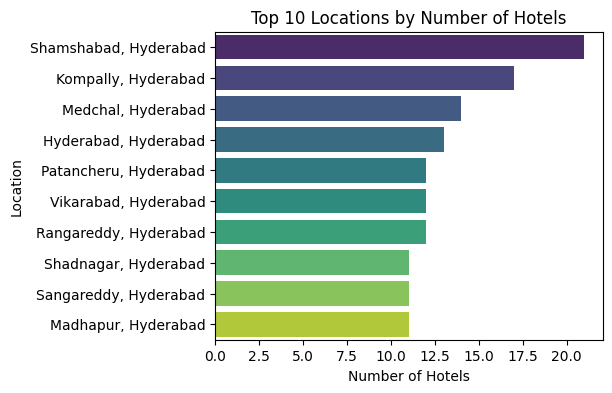

In [174]:
# ── Chart 6: Top 10 Locations (Horizontal Bar)
plt.figure(figsize=(5,4))
top_loc = df1["Locations"].value_counts().head(10)
sns.barplot(x=top_loc.values, y=top_loc.index, palette="viridis")
plt.title("Top 10 Locations by Number of Hotels")
plt.xlabel("Number of Hotels")
plt.ylabel("Location")
plt.show()
# INSIGHT: Shamshabad leads (21 hotels), followed by Kompally and Medchal —
# all Hyderabad suburbs. OYO focuses on peripheral/airport-adjacent zones.


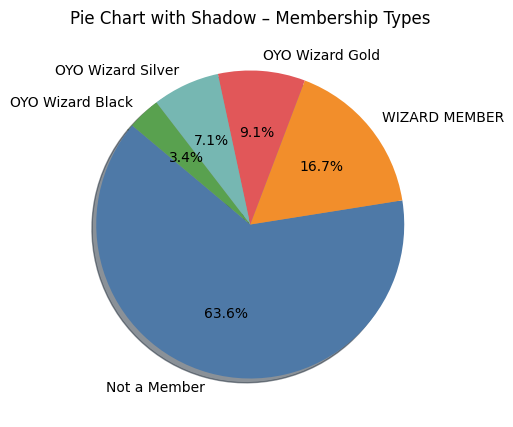

In [21]:
colors5 = [
    "#4E79A7",
    "#F28E2B", 
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#EDC948",
    "#B07AA1", 
    "#FF9DA7" 
]
plt.figure(figsize=(8,5))

plt.pie(
    sizes_member,
    labels=labels_member,
    autopct="%1.1f%%",
    colors=colors5[:len(labels_member)],
    shadow=True,
    startangle=140,
)

plt.title("Pie Chart with Shadow – Membership Types",)

plt.show()

#### bivariate analysis

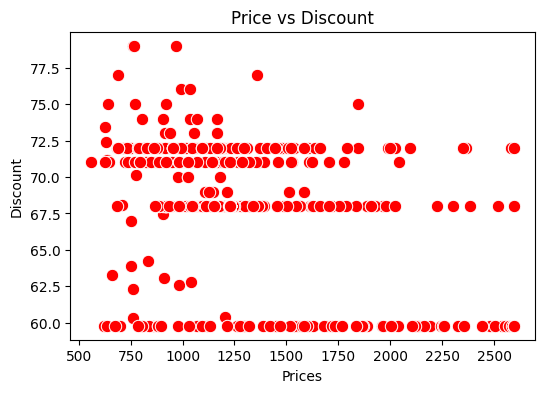

In [173]:
plt.figure(figsize=(6,4))

sns.scatterplot(x=df1["Prices"],
                y=df1["Discount"],
                color="red",
                s=80)

plt.title("Price vs Discount")
plt.xlabel("Prices")
plt.ylabel("Discount")

plt.show()

In [6]:
pip install squarify

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


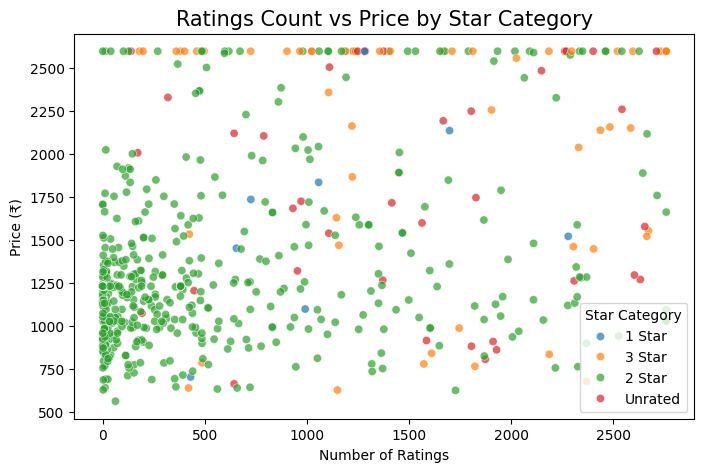

In [134]:
# ── Chart 2: Price vs Ratings Count by Star Category (Scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ratings_Count", y="Prices", hue="Star_Category",
                data=df1, palette="tab10", alpha=0.7)
plt.title("Ratings Count vs Price by Star Category", fontsize=15)
plt.xlabel("Number of Ratings")
plt.ylabel("Price (₹)")
plt.legend(title="Star Category")
plt.show()
# INSIGHT: Budget/2-Star hotels attract far more ratings (higher volume),
# while 3-Star and Unrated hotels are clustered with fewer ratings but
# higher prices — pointing to a niche, low-footfall premium segment.


C:\Users\chand\AppData\Local\Temp\ipykernel_16824\3912069240.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Star_Category",


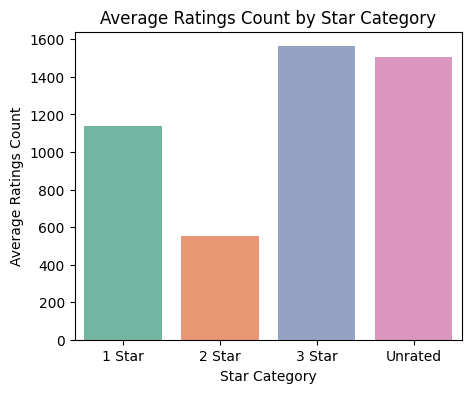

In [157]:
plt.figure(figsize=(5,4))

rating_data = df1.groupby("Star_Category")["Ratings_Count"].mean().reset_index()

sns.barplot(x="Star_Category",
            y="Ratings_Count",
            data=rating_data,
            palette="Set2")

plt.title("Average Ratings Count by Star Category")
plt.xlabel("Star Category")
plt.ylabel("Average Ratings Count")

plt.show()

#### Multivariate analysis

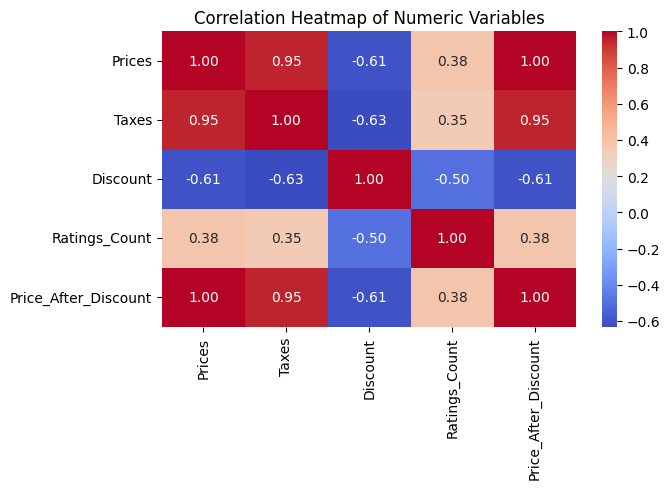

In [131]:
plt.figure(figsize=(7, 5))
numeric_cols = ["Prices", "Taxes", "Discount", "Ratings_Count", "Price_After_Discount"]
corr = df1[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


In [175]:
df1.to_csv("final visulization",index=True)